In [1]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
# import openseespy.postprocessing.Get_Rendering as opsplt

In [2]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [3]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [4]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (149399739652)>


In [5]:
elasto_mat_tag = 1
soil_thickness = 1000*UNIT.mm
etype = "PlaneStrain"


# Fixity definitions
fixXY = [1, 1]
fixXonly = [1, 0]
fixYonly = [0, 1]

# Storage for created nodes and elements
created_nodes = []
created_elements = []
block_registry = {}

# Start model
ops.wipe()
ops.model("Basic", "-ndm", 2, "-ndf", 2)

ops.nDMaterial(
            "PressureDependMultiYield02",
            5,
            2, # number of dimension
            1.8*UNIT.ton / UNIT.m3, #rho ton /m3
            9600.0, # ref shear modulus kpa
            27000.0, #ref bulk modulus kPa
            36, # friction angle
            0.1, # peak stress unit less
            101.0, #reference pressure kpa
            0.0, # press Dependent coefficient 
            26, #PT angle
            0.067, # Contrac 1 unit less
            0.23, # Contrac 3 unit less
            0.06, # dilatation 1 unit less
            0.27, # dilatation 3 unit less
            20, #no Yield Surf
            5.0, #Contrac 2 unit less
            3.0, #Contrac 3 unit less
            1.0, # liquefac1
            0.0, # liquefac2
            0.77, # e
            0.9, # cs1
            0.02, # cs2
            0.7, # cs3
            101.0, # pa kPa
        )
        # element thickness
        # body force in x-direction
        # body force in y-direction
        # create wrapper material for initial state analysis
soil_mat_tag = 1
ops.nDMaterial("InitialStateAnalysisWrapper", soil_mat_tag, 5, 2)

    #elasto_mat_tag = 100
    # Define material
    #ops.nDMaterial("ElasticIsotropic", elasto_mat_tag, E, nu, rho)

    # Define contact material
contact_mat = 2
ops.nDMaterial("ContactMaterial2D", contact_mat, 0.1, 1000.0, 0.0, 0.0) #kN/m

# Generate one block starting from node 1 and element 1
node_offset = 0
elem_offset = 1
node_offset, elem_offset = SF.generate_block(45.0, 32.0, 8.0, 8.0, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 0.5, 0.5 ,block_name="OAE_Soil_block")

InitialStateAnalysisWrapper nDmaterial - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington
ContactMaterial2D nDmaterial - Written: K.Petek, P.Mackenzie-Helnwein, P.Arduino, U.Washington


In [6]:
fix_bot_Yonly = SF.fix_nodes_by_range(start_id = 2, end_id = 16 , step  =1 , fixity = fixYonly, block_name="fixed_nodes")
ops.fix(1, 1, 1 )
ops.fix(17, 1, 1 )


In [7]:
eqdof = SF.apply_equal_dof_by_range(
    primary_start = 18 , primary_end = 273, primary_step = 17,
    secondary_start = 34, secondary_end = 289, secondary_step = 17,
    dofs=[1, 2], block_name="equal_dof_constraints")

In [8]:
Lagrange_a = SF.create_lagrange_nodes(start_id = 400, x_coord = 52.75, y_coord = 40.25, count = 15, block_name="LN_nodes")

In [9]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=True, show_nodal_loads = True)

In [10]:
ops.model("Basic", "-ndm", 2, "-ndf", 3)

In [11]:
next_node_id = SF.get_next_node_id(start_from=None)

In [12]:
pad_foundation = [
[45.250 , 40.250],
[45.750 , 40.250],
[46.250 , 40.250],
[46.750 , 40.250],
[47.250 , 40.250],
[47.750 , 40.250],
[48.250 , 40.250],
[48.750 , 40.250],
[49.250 , 40.250],
[49.750 , 40.250],
[50.250 , 40.250],
[50.750 , 40.250],
[51.250 , 40.250],
[51.750 , 40.250],
[52.250 , 40.250],
[52.750 , 40.250],
]

pad_noodes = SF.add_nodes_from_coordinates(coord_list = pad_foundation, start_id = next_node_id, block_name = "pad_nodes")

In [13]:
Iz = SF.FormRectangularInertia(b = 1.0, h = 0.1)
print(Iz)

8.333333333333336e-05


In [14]:
next_elem_id = SF.get_next_elem_id(start_from=None)

In [15]:
transFTag = 1
beam_secTag = 1
intTag = 401
Nint = 3

# Geometry transformation and section definition
ops.geomTransf("Linear", transFTag)
ops.section("Elastic", beam_secTag, 200*UNIT.gpa, 0.5*UNIT.m2, Iz*UNIT.m4)
ops.beamIntegration("Legendre", intTag, beam_secTag, Nint)

BEAM = SF.create_disp_beam_column_chain(beam_nodes = pad_noodes, beam_start_id = next_elem_id,
                                   transFTag = transFTag, intTag = intTag,
                                   block_name="beam_chain") 

In [16]:
#ground_slave_node = list(range(288, 273, -1))
ground_slave_node =list(range(274, 289))

In [17]:
next_elem_id = SF.get_next_elem_id(start_from=3050)

In [18]:
CONTACT_a = SF.create_beam_contact_chain(master_nodes = pad_noodes, slave_nodes = ground_slave_node, lagrange_nodes = Lagrange_a,
                               contact_mat = contact_mat, beam_start_id = next_elem_id,
                               width=500*UNIT.mm, tol1=1e-10, tol2=1e-10,
                               block_name="contact_beams")

BeamContact2D element - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington


In [19]:
ops.fix(415, 0, 1, 0)
ops.fix(430, 0, 1, 0)

In [20]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=True, show_nodal_loads = True)

In [21]:
OPSVIS = opst.vis.pyvista

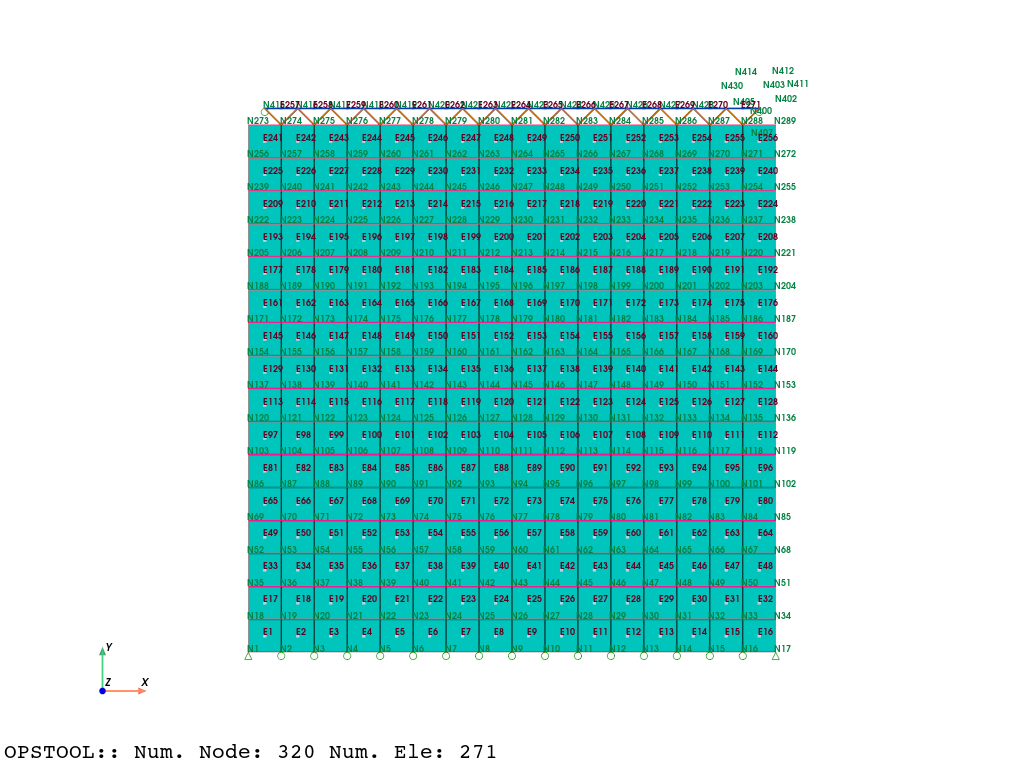

In [22]:
OPSVIS.set_plot_props(point_size=1, font_size=9, notebook=True)
OPSVIS.plot_model(show_node_numbering=True, show_ele_numbering=True).show(jupyter_backend="jupyterlab")

In [23]:
ODB = opst.post.CreateODB(
    odb_tag=1,
    model_update=True,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",
)

In [24]:
# define analysis parameters for gravity phase
ops.constraints("Transformation")
ops.test("NormDispIncr", 1e-05, 50, 0)
ops.algorithm("Newton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [25]:
# turn on initial state analysis feature
ops.InitialStateAnalysis("on")
# ensure soil material intially considers linear elastic behavior
ops.updateMaterialStage("-material", 1, "-stage", 0)
# set contact elements to be frictionless for gravity analysis
ops.setParameter("-val", 0, "-eleRange", 3050, 3064, "friction")
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()

InitialStateAnalysis ON


In [26]:
# update soil material to consider elastoplastic behavior and analyze a few more steps
ops.updateMaterialStage("-material", 1, "-stage", 1)
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()
# designate end of initial state analysis (zeros displacements, keeps state variables)
ops.InitialStateAnalysis("off")
# turn on frictional behavior for beam contact elements
ops.setParameter("-val", 1, "-eleRange", 3050, 3064, "friction")

InitialStateAnalysis OFF
Domain::addParameter - parameter with tag 0 already exists in model


In [27]:
# define analysis parameters for excavation phase
ops.wipeAnalysis()
ops.constraints("Transformation")
ops.test("NormDispIncr", 0.0001, 60)
ops.algorithm("KrylovNewton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [28]:
def remove_components(ele_tags, node_tags, nsteps=4):
    for etag in ele_tags:
        ops.remove("element", etag)
    for ntag in node_tags:
        ops.remove("node", ntag)
    # run analysis after object removal
    for _ in range(nsteps):
        ops.analyze(1)
        ODB.fetch_response_step()

In [29]:
PN_1 = 500000*UNIT.N
print(PN_1)
ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)
ops.load(423, 0, -PN_1, 0)
ops.analyze(1)

500.0


0

In [30]:
# remove objects associated with lift 1
# soil elements
ele_tags = []
ele_tags += []  # contact element
# soil nodes
node_tags = []
node_tags += []  # lagrange multiplier node

remove_components(ele_tags, node_tags, nsteps=4)

print("Lift 1 removed")

Lift 1 removed


In [31]:
PN_2 = 5000*UNIT.N
print(PN_2)
ops.load(417, 0, -PN_2, 0)
ops.analyze(1)

5.0


0

In [32]:
# remove objects associated with lift 1
# soil elements
ele_tags = []
ele_tags += []  # contact element
# soil nodes
node_tags = []
node_tags += []  # lagrange multiplier node

remove_components(ele_tags, node_tags, nsteps=4)

print("Lift 2 removed")

Lift 2 removed


In [33]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=True, show_nodal_loads = True)

In [34]:
ODB.save_response(zlib=True)
import matplotlib.pyplot as plt
import opstool as opst
import opstool.vis.pyvista as opsvis

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

In [35]:
opsvis.set_plot_props(point_size=0, line_width=5, cmap="turbo", notebook=True)
opsvis.set_plot_props(
    scalar_bar_kargs={
        "label_font_size": 12,
        "title_font_size": 13,
        "position_x": 0.85,  # 0--1
    }
)

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

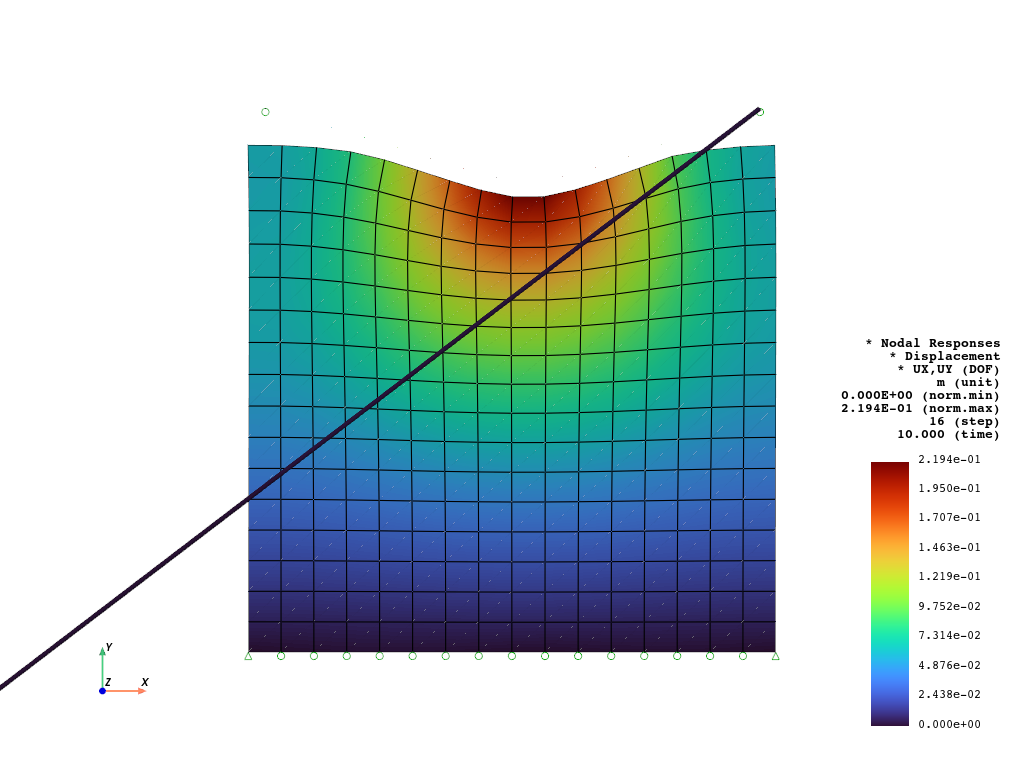

: 

In [ ]:
opsvis.plot_nodal_responses(
    odb_tag=1,
    slides=True,
    scale=2,
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).show(jupyter_backend="jupyterlab")

In [ ]:
opsvis.plot_nodal_responses_animation(
    odb_tag=1,
    framerate=2,
    scale=2,
    savefig="NodalRespAnimationA.gif",
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

In [ ]:
plotter = opsvis.plot_frame_responses(
    odb_tag=1,
    resp_type="sectionForces",
    resp_dof="MZ",
    unit_symbol="kN·m",
    show_values="eleMaxMin",
    scale=3,
    slides=True,
    style="surface",
    show_model=False,  # plot all model
    opacity=1.0,
    show_bc=False,
)
plotter.show(jupyter_backend="jupyterlab")